# 01. Exploracion de datasets

Entrega evaluativa 2 - Análisis de datos

## Dataset 1: Airline Passenger Satisfaction

- **Tipo de dato:** Tabular
- **Fuente:** Secundaria (encuesta de satisfacción de una aerolínea, ya procesada y publicada en Kaggle)
- **Tamaño:** 129,880 filas (103,904 train + 25,976 test), 25 columnas
- **Documentación:** Alta — incluye diccionario de variables y notebooks de referencia en Kaggle
- **Posibles aplicaciones:** Predicción de satisfacción del cliente, segmentación de pasajeros, análisis de factores que afectan la experiencia de vuelo

In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


In [2]:

path1 = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")
print("Path to dataset files:", path1)

Path to dataset files: C:\Users\Usuario\.cache\kagglehub\datasets\teejmahal20\airline-passenger-satisfaction\versions\1


In [3]:
import os

archivos = os.listdir(path1)
print("Archivos:", archivos)

df1 = pd.read_csv(f"{path1}\\{archivos[0]}")
print(df1.shape)
df1.head()

df1_train = pd.read_csv(f"{path1}\\train.csv")
df1_test = pd.read_csv(f"{path1}\\test.csv")

print("Train:", df1_train.shape)
print("Test:", df1_test.shape)
print("Total combinado:", df1_train.shape[0] + df1_test.shape[0])

Archivos: ['test.csv', 'train.csv']
(25976, 25)
Train: (103904, 25)
Test: (25976, 25)
Total combinado: 129880


**Nota:** el dataset viene dividido en train/test.

In [4]:
df1_completo = pd.concat([df1_train, df1_test], ignore_index=True)
print(df1_completo.shape)
df1_completo.head()

(129880, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## Dataset 2: Chest X-Ray Images (Pneumonia)

- **Tipo de dato:** Imágenes
- **Fuente:** Secundaria (radiografías clínicas recopiladas y publicadas para investigación)
- **Tamaño:** ~5,856 imágenes
- **Documentación:** Alta — dataset ampliamente citado en publicaciones científicas
- **Posibles aplicaciones:** Clasificación de neumonía vs. normal, apoyo diagnóstico automatizado en salud

In [5]:
path2 = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print(path2)

C:\Users\Usuario\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [6]:
ruta_real = os.path.join(path2, "chest_xray", "chest_xray")

for split in ["train", "test", "val"]:
    for clase in ["NORMAL", "PNEUMONIA"]:
        carpeta = os.path.join(ruta_real, split, clase)
        n = len([f for f in os.listdir(carpeta) if f.endswith(('.jpeg', '.jpg', '.png'))])
        print(f"{split}/{clase}: {n} imágenes")

train/NORMAL: 1341 imágenes
train/PNEUMONIA: 3875 imágenes
test/NORMAL: 234 imágenes
test/PNEUMONIA: 390 imágenes
val/NORMAL: 8 imágenes
val/PNEUMONIA: 8 imágenes


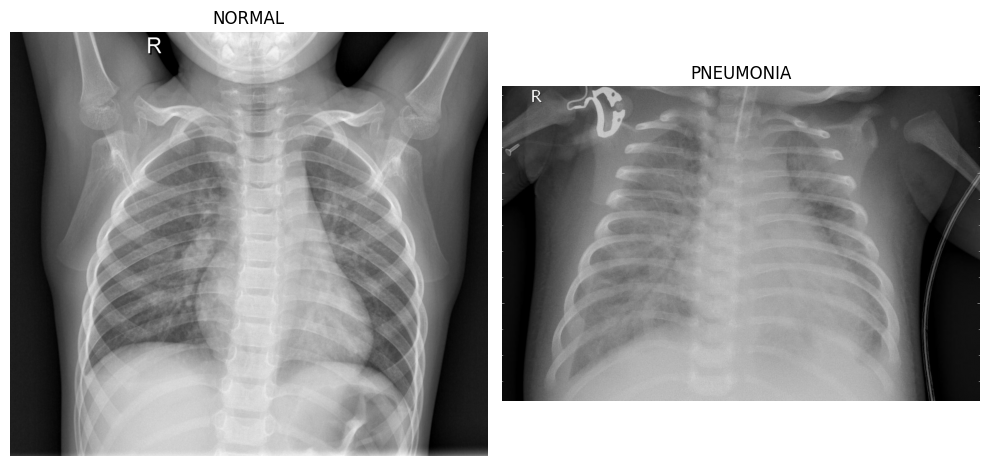

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
for ax, clase in zip(axes, ["NORMAL", "PNEUMONIA"]):
    carpeta = os.path.join(ruta_real, "train", clase)
    imagenes_validas = [f for f in os.listdir(carpeta) if f.endswith(('.jpeg', '.jpg', '.png'))]
    primera_imagen = imagenes_validas[0]
    img = Image.open(os.path.join(carpeta, primera_imagen))
    ax.imshow(img, cmap='gray')
    ax.set_title(clase)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Dataset 3: IMDB Movie Reviews (análisis de sentimiento)

- **Tipo de dato:** Texto
- **Fuente:** Secundaria (reseñas públicas de usuarios, recopiladas y etiquetadas para investigación de NLP)
- **Tamaño:** 50,000 reseñas (25,000 positivas / 25,000 negativas)
- **Documentación:** Alta — es un benchmark estándar ampliamente usado en la literatura de procesamiento de lenguaje natural
- **Posibles aplicaciones:** Clasificación de sentimiento, análisis de opinión, entrenamiento de modelos de NLP

In [8]:
path3 = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print(path3)

C:\Users\Usuario\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1


In [9]:
archivos3 = os.listdir(path3)
print("Archivos:", archivos3)

df3 = pd.read_csv(f"{path3}\\{archivos3[0]}")
print(df3.shape)
df3.head()

Archivos: ['IMDB Dataset.csv']
(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Justificación de la elección: Airline Passenger Satisfaction

Se selecciona este dataset como base para las Fases 2 y 3 del proyecto por las siguientes razones:

- **Completitud:** 129,880 registros con 25 variables, tamaño suficiente para un análisis robusto sin ser inmanejable.
- **Relevancia:** combina variables numéricas (edad, distancia de vuelo, tiempos de demora) y categóricas (género, tipo de cliente, clase de viaje) — ideal para aplicar EDA multivariado, codificación de categóricas, escalado y PCA con sentido interpretable.
- **Documentación:** dataset ampliamente documentado en Kaggle, con diccionario de variables claro.
- **Manejabilidad:** a diferencia de los datasets de imágenes y texto (que requieren procesamiento especializado como visión computacional o NLP), este dataset tabular permite aplicar directamente todas varias de las técnicas que hemos visto.

Los datasets de imágenes (Chest X-Ray) y texto (IMDB) se documentaron como parte de la exploración inicial, pero se descartan para el análisis profundo por requerir técnicas de preprocesamiento mas especializadas.